Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking for files...
['Fake.csv', 'True.csv']

✅ True.csv loaded  — shape: (21417, 4)
✅ Fake.csv loaded  — shape: (23481, 4)

True.csv columns : ['title', 'text', 'subject', 'date']
Fake.csv columns : ['title', 'text', 'subject', 'date']

📊 Combined dataset shape : (44898, 2)
Label distribution :
label
1    23481
0    21417
Name: count, dtype: int64

Sample text :
 BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of this. To them, it s  fake

✅ After cleaning : (44889, 2)

Train size : 35,911
Test size  : 8,978

  TRAINING & EVALUATING MODELS

▶  Training Logistic Regression...
   Accuracy : 0.9958  |  CV-5 : 0.9948  |  AUC : 0.9998

▶  Trai

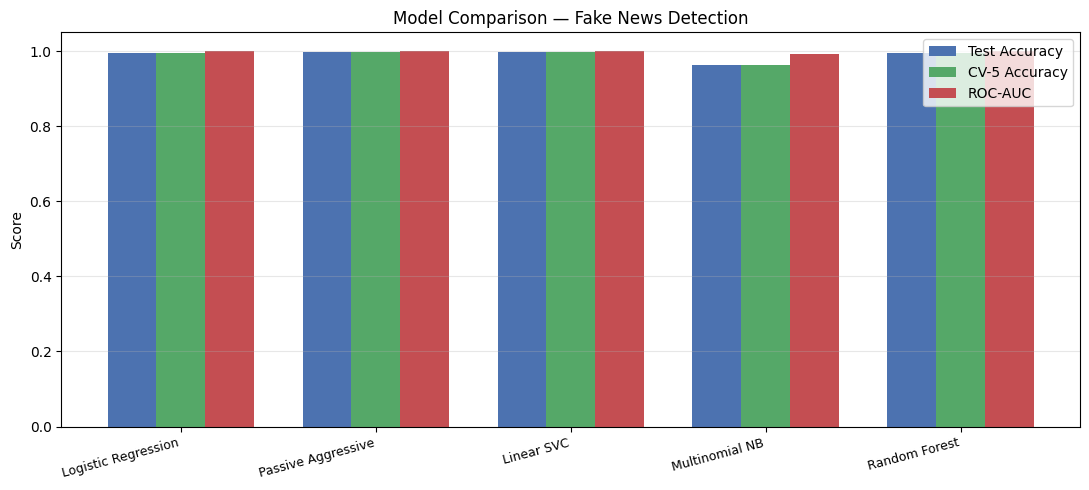

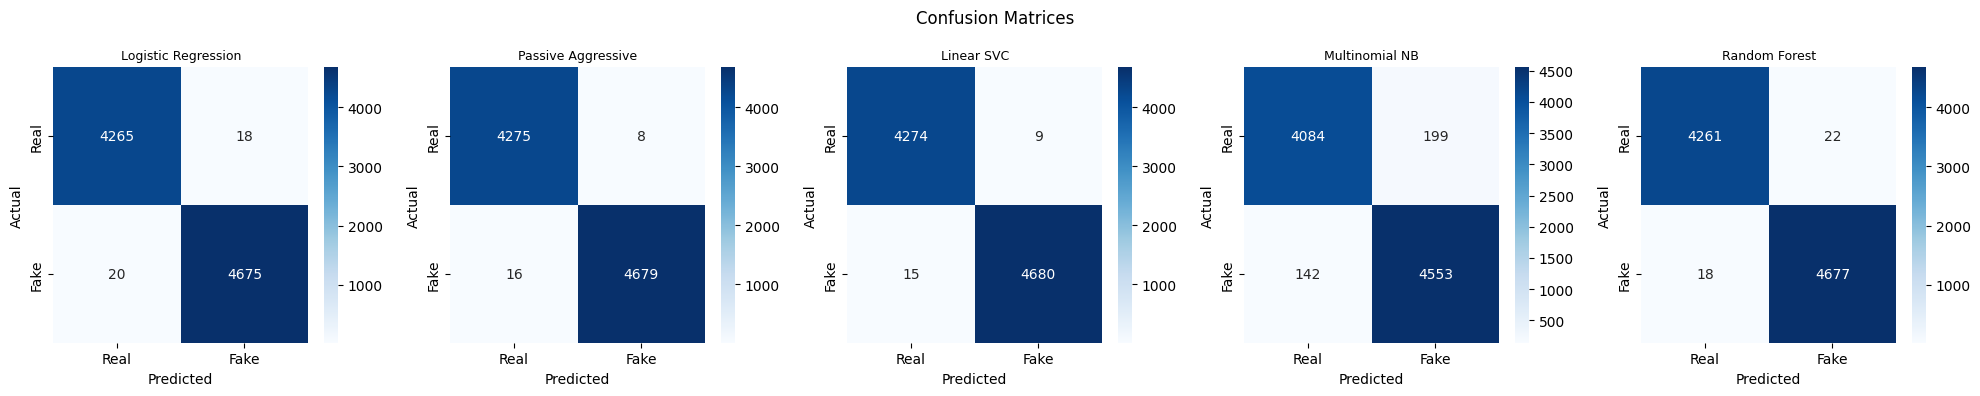

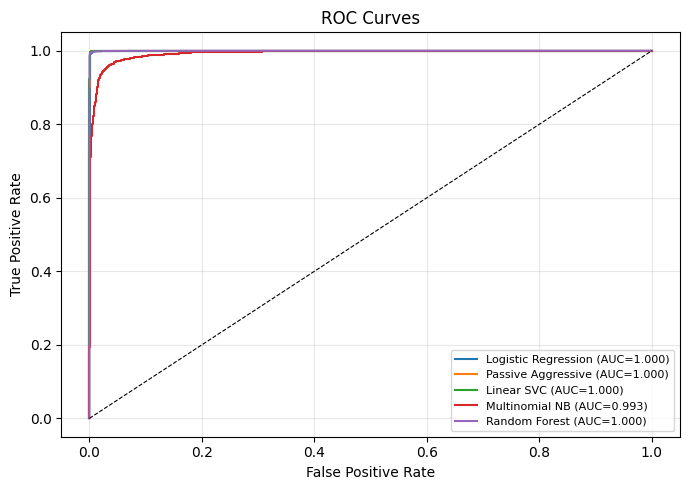


✅ Best model : 'Passive Aggressive'
   AUC        : 0.9999
   Saved to   : /content/drive/MyDrive/fake news detection/best_model.joblib

  INFERENCE DEMO

  ✅ REAL  (confidence: 50.2%)
  Text : The Federal Reserve raised interest rates by 0.25% to combat inflation.

  🚨 FAKE  (confidence: 68.8%)
  Text : Doctors HATE this man — he cured cancer with one weird trick!

  🚨 FAKE  (confidence: 69.1%)
  Text : NASA confirms discovery of water ice on the surface of Mars.

  🚨 FAKE  (confidence: 68.8%)
  Text : Government puts 5G chips in vaccines to track citizens secretly.

  🚨 FAKE  (confidence: 51.9%)
  Text : Stock markets fell sharply following disappointing jobs report data.


In [1]:
"""
Fake News Detection — Complete Single Script
============================================
Run this entirely in Google Colab.
Make sure True.csv and Fake.csv are in your Google Drive.
"""

# ─────────────────────────────────────────────
# STEP 1 — MOUNT GOOGLE DRIVE
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)


# ─────────────────────────────────────────────
# STEP 2 — LOAD DATASET FROM DRIVE
# ─────────────────────────────────────────────

# ✅ UPDATE THIS PATH if your files are in a different folder
FOLDER = "/content/drive/MyDrive/fake news detection"

real_path = os.path.join(FOLDER, "True.csv")
fake_path = os.path.join(FOLDER, "Fake.csv")

print("Looking for files...")
print(os.listdir(FOLDER))  # confirm files are visible

real_df = pd.read_csv(real_path)
fake_df = pd.read_csv(fake_path)

print(f"\n✅ True.csv loaded  — shape: {real_df.shape}")
print(f"✅ Fake.csv loaded  — shape: {fake_df.shape}")
print(f"\nTrue.csv columns : {real_df.columns.tolist()}")
print(f"Fake.csv columns : {fake_df.columns.tolist()}")


# ─────────────────────────────────────────────
# STEP 3 — COMBINE & LABEL
# ─────────────────────────────────────────────

real_df["label"] = 0   # 0 = Real
fake_df["label"] = 1   # 1 = Fake

# Combine title + text for richer features
for df in [real_df, fake_df]:
    if "title" in df.columns and "text" in df.columns:
        df["text"] = df["title"].fillna("") + " " + df["text"].fillna("")
    elif "title" in df.columns:
        df["text"] = df["title"].fillna("")

df = pd.concat(
    [real_df[["text", "label"]], fake_df[["text", "label"]]],
    ignore_index=True
)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"\n📊 Combined dataset shape : {df.shape}")
print(f"Label distribution :\n{df['label'].value_counts()}")
print(f"\nSample text :\n{df['text'].iloc[0][:300]}")


# ─────────────────────────────────────────────
# STEP 4 — TEXT PREPROCESSING
# ─────────────────────────────────────────────

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)           # HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # URLs
    text = re.sub(r"[^a-z\s]", " ", text)           # non-alpha
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(clean_text)
df = df[df["text"].str.len() > 10].reset_index(drop=True)

print(f"\n✅ After cleaning : {df.shape}")


# ─────────────────────────────────────────────
# STEP 5 — TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

X = df["text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")


# ─────────────────────────────────────────────
# STEP 6 — BUILD PIPELINES
# ─────────────────────────────────────────────

tfidf_params = dict(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    stop_words="english"
)

pipelines = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",  LogisticRegression(max_iter=1000, C=5.0, solver="lbfgs"))
    ]),
    "Passive Aggressive": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",  PassiveAggressiveClassifier(max_iter=1000, C=0.5))
    ]),
    "Linear SVC": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",  LinearSVC(max_iter=2000, C=1.0))
    ]),
    "Multinomial NB": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",  MultinomialNB(alpha=0.1))
    ]),
    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=20_000, ngram_range=(1, 1),
                                  sublinear_tf=True, stop_words="english")),
        ("clf",  RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))
    ]),
}


# ─────────────────────────────────────────────
# STEP 7 — TRAIN & EVALUATE ALL MODELS
# ─────────────────────────────────────────────

results = {}

print(f"\n{'='*60}")
print("  TRAINING & EVALUATING MODELS")
print(f"{'='*60}\n")

for name, pipeline in pipelines.items():
    print(f"▶  Training {name}...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    try:
        scores = pipeline.decision_function(X_test)
    except AttributeError:
        scores = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, scores)
    cv  = cross_val_score(pipeline, X_train, y_train,
                          cv=5, scoring="accuracy", n_jobs=-1).mean()

    results[name] = {
        "pipeline": pipeline,
        "accuracy": acc,
        "cv_score": cv,
        "auc":      auc,
        "y_pred":   y_pred,
        "scores":   scores,
        "report":   classification_report(y_test, y_pred,
                        target_names=["Real", "Fake"])
    }

    print(f"   Accuracy : {acc:.4f}  |  CV-5 : {cv:.4f}  |  AUC : {auc:.4f}\n")


# ─────────────────────────────────────────────
# STEP 8 — DETAILED REPORTS
# ─────────────────────────────────────────────

print(f"\n{'='*60}")
print("  DETAILED CLASSIFICATION REPORTS")
print(f"{'='*60}")

for name, res in results.items():
    print(f"\n── {name} ──")
    print(res["report"])


# ─────────────────────────────────────────────
# STEP 9 — VISUALISATIONS
# ─────────────────────────────────────────────

names = list(results.keys())
accs  = [results[n]["accuracy"] for n in names]
cvs   = [results[n]["cv_score"] for n in names]
aucs  = [results[n]["auc"]      for n in names]

# ── Model comparison bar chart ──
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(names))
w = 0.25
ax.bar(x - w, accs, w, label="Test Accuracy", color="#4C72B0")
ax.bar(x,     cvs,  w, label="CV-5 Accuracy", color="#55A868")
ax.bar(x + w, aucs, w, label="ROC-AUC",        color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Fake News Detection")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Confusion matrices ──
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4))
for ax, name in zip(axes, names):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices", fontsize=12)
plt.tight_layout()
plt.show()

# ── ROC curves ──
fig, ax = plt.subplots(figsize=(7, 5))
for name in names:
    fpr, tpr, _ = roc_curve(y_test, results[name]["scores"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# STEP 10 — SAVE BEST MODEL TO DRIVE
# ─────────────────────────────────────────────

best_name = max(results, key=lambda n: results[n]["auc"])
best_pipe = results[best_name]["pipeline"]
save_path = os.path.join(FOLDER, "best_model.joblib")
joblib.dump(best_pipe, save_path)

print(f"\n✅ Best model : '{best_name}'")
print(f"   AUC        : {results[best_name]['auc']:.4f}")
print(f"   Saved to   : {save_path}")


# ─────────────────────────────────────────────
# STEP 11 — INFERENCE DEMO
# ─────────────────────────────────────────────

def predict(text: str, pipeline) -> dict:
    cleaned = clean_text(text)
    label   = pipeline.predict([cleaned])[0]
    try:
        proba      = pipeline.predict_proba([cleaned])[0]
        confidence = float(max(proba))
        fake_prob  = float(proba[1])
    except AttributeError:
        score      = pipeline.decision_function([cleaned])[0]
        fake_prob  = float(1 / (1 + np.exp(-score)))
        confidence = float(1 / (1 + np.exp(-abs(score))))
    return {
        "label":      "FAKE" if label == 1 else "REAL",
        "confidence": confidence,
        "fake_prob":  fake_prob,
    }

sample_articles = [
    "The Federal Reserve raised interest rates by 0.25% to combat inflation.",
    "Doctors HATE this man — he cured cancer with one weird trick!",
    "NASA confirms discovery of water ice on the surface of Mars.",
    "Government puts 5G chips in vaccines to track citizens secretly.",
    "Stock markets fell sharply following disappointing jobs report data.",
]

print(f"\n{'='*60}")
print("  INFERENCE DEMO")
print(f"{'='*60}")

for article in sample_articles:
    res = predict(article, best_pipe)
    tag = "🚨 FAKE" if res["label"] == "FAKE" else "✅ REAL"
    print(f"\n  {tag}  (confidence: {res['confidence']:.1%})")
    print(f"  Text : {article}")

In [2]:
import joblib
from google.colab import drive

model = joblib.load("/content/drive/MyDrive/fake news detection/best_model.joblib")

# Test it
test_texts = [
    "The Federal Reserve raised interest rates to combat inflation.",
    "Doctors HATE this man — he cured cancer with one weird trick!",
]

for text in test_texts:
    cleaned = clean_text(text)
    pred = model.predict([cleaned])[0]
    print(f"{'FAKE' if pred == 1 else 'REAL'} — {text[:60]}")

REAL — The Federal Reserve raised interest rates to combat inflatio
FAKE — Doctors HATE this man — he cured cancer with one weird trick
